In [17]:
%matplotlib widget
import numpy as np
from collections import OrderedDict
import os

# Setup the module path.
import sys
sys.path.append(r"C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt")
sys.path.append(r"C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt_contrib")
sys.path.append(r"C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt_analysis")
sys.path.append(r"C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\mirfusion_library")
sys.path.append(r"C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\mirxics_jax")

## Start Logging
import logging
logging.basicConfig(level=logging.DEBUG)
logging.getLogger('matplotlib').setLevel(logging.WARNING)
logging.getLogger('PIL').setLevel(logging.WARNING)
logging.getLogger('h5py').setLevel(logging.WARNING)
logging.getLogger('jax').setLevel(logging.WARNING)

from mirutil import mirprint

# Import xicsrt modules
import xicsrt
from xicsrt.util import profiler

from w7x_npablant import xicsrt_w7x_lalston

In [18]:
config = xicsrt_w7x_lalston.get_config()
config = xicsrt_w7x_lalston.initialize(config)

config['general']['comment'] = """
W7-X ray-tracing run using randomly generated spline profiles.

Ion-temperature, electron-temperature, and emissivity profiles are
generated from randomized spline knots. Velocity is currently disabled.
"""

config['general']['number_of_runs'] = 1
config['general']['number_of_iter'] = 1
config['general']['save_images'] = True
config['general']['make_directories'] = True

config['general']['keep_history'] = True

config['general']['output_path'] = r"C:\Users\leila\Documents\Visual Studio\pppl_xics_2026"
config['general']['output_suffix'] = '_spline_test_00'

config['sources']['plasma']['wavelength_dist'] = 'ar16_voigt'
config['sources']['plasma']['wout_file'] = r"C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\wout.nc"
config['sources']['plasma']['enable_velocity'] = False
config['sources']['plasma']['enable_flux_compression'] = False
config['sources']['plasma']['time_resolution'] = 1e-3
config['sources']['plasma']['spread'] = np.radians(1.0)
config['sources']['plasma']['xsize'] = 0.15

In [19]:
from xicsrt import xicsrt_config, xicsrt_io
from xicsrt.tools import xicsrt_spline

generated_profiles = {
    "profile_ion_temp": xicsrt_spline.generate_random_ion_temp(),
    "profile_electron_temp": xicsrt_spline.generate_random_electron_temp(),
    "profile_emissivity": xicsrt_spline.generate_random_emissivity(),
    "profile_perpendicular_velocity": xicsrt_spline.generate_random_perpendicular_velocity(),
    "profile_parallel_velocity": xicsrt_spline.generate_random_parallel_velocity(),
}

config_new = {
    "sources": {
        "plasma": generated_profiles
    }
}

xicsrt_config.update_config(
    config,
    config_new,
    strict=False,
    update=True,
)

{'general': {'pathlist': ['C:\\Users\\leila\\Documents\\Visual Studio\\pppl_xics_2026\\xicsrt_analysis\\w7x_npablant\\sources'],
  'number_of_iter': 1,
  'number_of_runs': 1,
  'output_path': 'C:\\Users\\leila\\Documents\\Visual Studio\\pppl_xics_2026',
  'output_suffix': '_spline_test_00',
  'save_images': True,
  'random_seed': None,
  'comment': '\nW7-X ray-tracing run using randomly generated spline profiles.\n\nIon-temperature, electron-temperature, and emissivity profiles are\ngenerated from randomized spline knots. Velocity is currently disabled.\n',
  'make_directories': True,
  'keep_history': True},
 'sources': {'plasma': {'class_name': 'XicsrtPlasmaW7xSpline',
   'origin': [-5.15, 1.95, 0.15],
   'zaxis': array([-0.93485826,  0.35397546,  0.02722888]),
   'xaxis': array([ 0.35410675,  0.93520501, -0.        ]),
   'target': [-8.606890681240294, 3.2920701414857128, 0.07353941906311681],
   'xsize': 0.15,
   'ysize': 1.7,
   'zsize': 1.5,
   'profile_ion_temp': {'x_knots': arr

In [23]:
profiler.resetProfiler()
profiler.startProfiler()

result = xicsrt.raytrace(config)

xicsrt_io.save_config(
    config, 
    filename="raytrace_config.json", 
    path=config['general']['output_path']
)

profiler.stopProfiler()
#print('', flush=True)
profiler.report()

INFO:xicsrt.xicsrt_raytrace:Starting run: 1 of 1
INFO:xicsrt.xicsrt_raytrace:Seeding np.random with None
INFO:xicsrt.xicsrt_raytrace:Starting iteration: 1 of 1
C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\DESC\desc\vmec.py:93: UserWarning: VMEC output appears to be from version 8.48 while DESC is only designed for compatibility with VMEC version 9. Some data may not be loaded correctly.
  warnings.warn(
INFO:xicsrt.xicsrt_io:Saved image: C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt_crystal__spline_test_00_0000.tif
INFO:xicsrt.xicsrt_io:Saved image: C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt_detector__spline_test_00_0000.tif
INFO:xicsrt.xicsrt_io:Saved image: C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt_crystal__spline_test_00.tif
INFO:xicsrt.xicsrt_io:Saved image: C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt_detector__spline_test_00.tif



Rays Generated: 1.061e+05
Rays Detected:  3.600e+01
Efficiency:     3.394e-04 ± 5.7e-05 (0.03394%)



INFO:xicsrt.xicsrt_io:Config saved to C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\raytrace_config.json
INFO:xicsrt.util.profiler:name                      total           single          calls 
INFO:xicsrt.util.profiler:raytrace                  0:02:08.724445  0:02:08.724445       1
INFO:xicsrt.util.profiler:raytrace_single           0:02:08.701274  0:02:08.701274       1
INFO:xicsrt.util.profiler:_raytrace_iter            0:02:08.663060  0:02:08.663060       1
INFO:xicsrt.util.profiler:Ray Bundle Generation     0:01:40.460505  0:00:00.030369    3308
INFO:xicsrt.util.profiler:generate_rays             0:01:39.245023  0:00:00.030002    3308
INFO:xicsrt.util.profiler:generate_wavelength       0:01:37.852307  0:00:00.029581    3308
INFO:xicsrt.util.profiler:Bundle Input Generation   0:00:23.197741  0:00:23.197741       1
INFO:xicsrt.util.profiler:Fluxspace from Realspace  0:00:22.157952  0:00:22.157952       1
INFO:xicsrt.util.profiler:Realspace from Fluxspace  0:00:01.031987  

C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\DESC\desc\vmec.py:93: UserWarning: VMEC output appears to be from version 8.48 while DESC is only designed for compatibility with VMEC version 9. Some data may not be loaded correctly.
  warnings.warn(


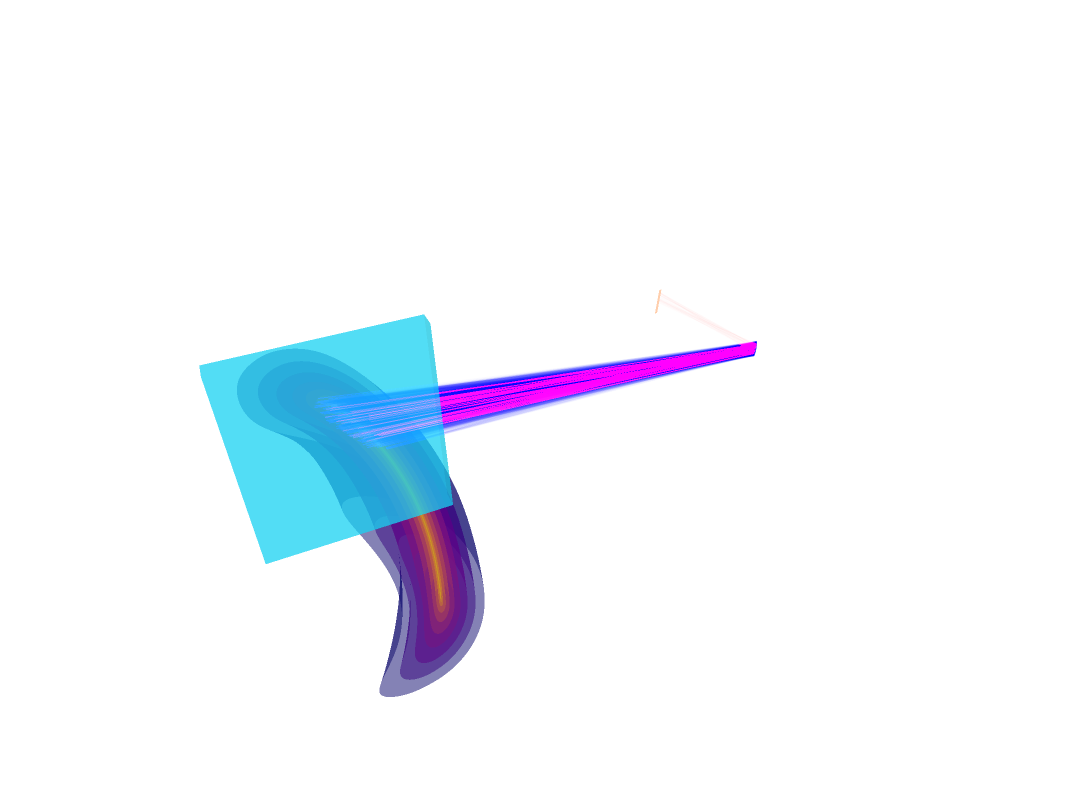

In [24]:
import xicsrt.visual.xicsrt_3d__plotly as xicsrt_3d

fig = xicsrt_3d.figure()
# xicsrt_3d.add_fluxsurfaces(result['config'], range_n=(0, np.pi*2))
xicsrt_3d.add_fluxsurfaces(result['config'], range_n=(0+np.pi*4/5, np.pi/10+np.pi*4/5))
xicsrt_3d.add_rays(result)
xicsrt_3d.add_optics(result['config'])
xicsrt_3d.add_sources(result['config'])

fig.update_layout(
    autosize=False,
    width=1000,
    height=800,
)

xicsrt_3d.show()

INFO:xicsrt.visual.xicsrt_2d__matplotlib:Histogram bins, size:0.000400 num: 120
INFO:xicsrt.visual.xicsrt_2d__matplotlib:Histogram bins, size:0.000400 num: 300


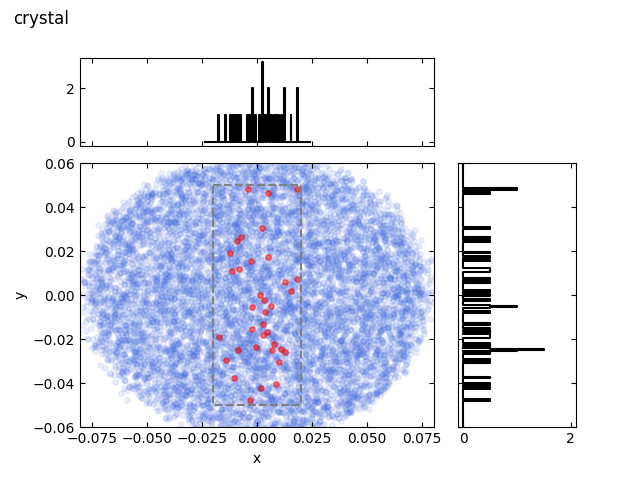

In [27]:
import xicsrt.visual.xicsrt_2d__matplotlib as xicsrt_2d
fig = xicsrt_2d.plot_intersect(result, 'crystal', aspect='equal')

INFO:xicsrt.visual.xicsrt_2d__matplotlib:Histogram bins, size:0.000172 num: 234
INFO:xicsrt.visual.xicsrt_2d__matplotlib:Histogram bins, size:0.000172 num:1770


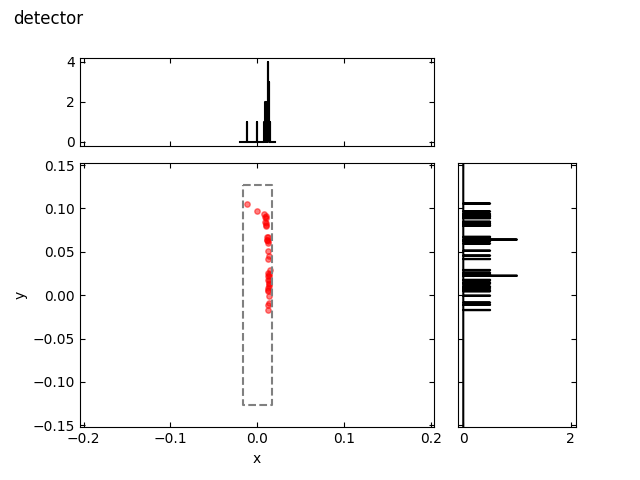

In [26]:
import xicsrt.visual.xicsrt_2d__matplotlib as xicsrt_2d
fig = xicsrt_2d.plot_intersect(result, 'detector', aspect='equal')

In [25]:
import xicsrt.visual.xicsrt_2d__matplotlib as xicsrt_2d
fig = xicsrt_2d.plot_image(result, 'detector')